Modified from "Using Deep Learning for Flexible and Scalable Earthquake Forecasting"  
Reference: [Zenodo](https://zenodo.org/records/8161777)

In [1]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import torch
import src  
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import functools
import os
import importlib
sys.path.append(str(Path.cwd().parent))
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
set_seed(0) 

In [4]:
checkpoint_dir  =  Path("../checkpoints/etas_20251231-123806") 
checkpoint_path1 = checkpoint_dir/ "best_model_1.pth"
checkpoint_dir2 = Path("../checkpoints/etas_20251221-224107") 
checkpoint_path2 = checkpoint_dir2/ "last_model_1.pth"

## Loading a trained model

In [5]:
from src.models.builders import ModelBuilder
from src.train.config_setup import load_and_prepare_model
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model, args = load_and_prepare_model(checkpoint_path=checkpoint_path1,device=device)
# model2,_ = load_and_prepare_model(checkpoint_path=checkpoint_path2,device=device)

load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'model': 'etas', 'num_event_types': 1, 'pad_token_id': 1, 'task_type': 'tpp', 'bg_model': 'mamba', 'bg_model_cfg': {'d_feature': 1, 'd_state': 64, 'd_model': 16, 'model_type': 'mamba', 'scale_init': 200.0}, 'bg_learning_rate': 0.0005, 'base_rate_init': 0.26, 'batch_size': 1, 'accumulation_steps': 1, 'warmup_ratio': 0.1, 'learning_rate': 0.01, 'weight_decay': 0.005, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'step_warmup', 'step_lr_step_size_ratio': 0.2, 'step_lr_gamma': 0.8, 'dim': 1, 'epochs': 1000, 'save_dir': 'checkpoints/etas_20251231-123806', 'cuda_id': '0', 'dataset': 'PNR_1z', 'seed': 0, 'minibatch_training': False, 'split_by_time': True, 'time_order': ['train', 'val', 'test'], 'catalog_cfg': {'freq': '1D', 'mag_completeness': -1.5}, 'cuda': True, 'tau_mean': 0.00913934875279665, 'tau_min': 3.832500539

In [4]:
# model.bg_model = model2.bg_model

In [6]:
if model.bg_model is not None:
   print(f" model.bg_model._scale: {model.bg_model._scale}")

 model.bg_model._scale: 191.79330444335938


In [7]:
model.print_params()

ETAS model parameters:
  p = 2.012207940558003
  c = 0.004334559894616285
  mu = 0.12350356012699254
  k = 0.002749546662745398
  K = 0.6697217156037166
  alpha = 0.2103566468210947
  alpha_e = 0.484364079182466
  b = 1.2355434894561768
  M_c = -1.5
  M_m = 10.0


## Loading the catalog

In [8]:
args.catalog_cfg

{'freq': '1D', 'mag_completeness': -1.5}

In [9]:
catalog_ds_class = catalog.Catalog.by_name(f"{args.dataset}-Standard")
catalog_cfg = getattr(args, 'catalog_cfg', {})
catalog_ds = catalog_ds_class(root_dir=f'../data/{args.dataset}/raw', **catalog_cfg)

metadata = catalog_ds.metadata
start_ts = pd.to_datetime(metadata['start_ts'])
end_ts = pd.to_datetime(metadata['end_ts'])
val_start_ts = pd.to_datetime(metadata['val_start_ts'])
test_start_ts = pd.to_datetime(metadata['test_start_ts'])

freq_td = pd.to_timedelta(metadata['freq'])
freq = freq_td.total_seconds() 

print(f'train end: {(val_start_ts - start_ts) / freq_td}, val_end: {(test_start_ts - start_ts) / freq_td}')

Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/PNR_1z/raw/2e94e6c6.
train end: 37.666666666666664, val_end: 59.666666666666664


In [10]:
catalog_ds.train[0].arrival_times

tensor([ 1.2314,  1.2320,  1.2326,  ..., 37.2629, 37.3010, 37.3434])

## Prepare the data

We trained the TPP model using the `train` and `val` sequences. Now we will use the unseen section of the `test` sequence (in orange) to evaluate forecasting performance of the model.

<Axes: xlabel='Arrival time (days)', ylabel='Magnitude'>

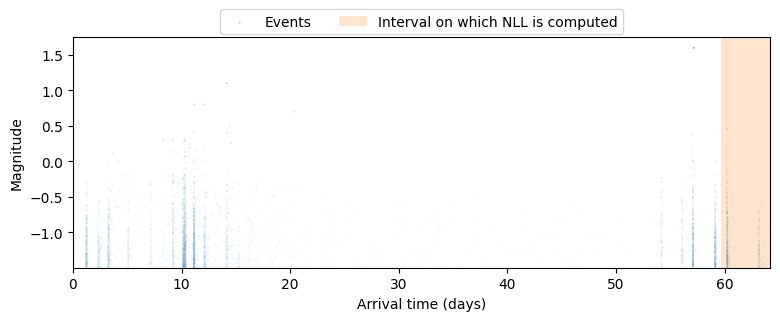

In [11]:
from src.utils.visualization import visualize_sequence
test_seq = catalog_ds.test[0]
train_seq = catalog_ds.train[0]
val_seq  = catalog_ds.val[0]
visualize_sequence(test_seq, show_nll=True)

In [12]:
test_batch = src.data.Batch.from_list([test_seq])
test_batch.to(device)
train_batch = src.data.Batch.from_list([train_seq])
train_batch.to(device)
val_batch = src.data.Batch.from_list([val_seq])
val_batch.to(device)

Batch(
  inter_times: [1, 5291],
  arrival_times: [1, 5291],
  t_start: [1],
  t_end: [1],
  t_nll_start: [1],
  nll_event_mask: [1, 5291],
  input_mask: [1, 5291],
  start_idx: [1],
  end_idx: [1],
  non_pad_mask: [1, 5291],
  type_seq: [1, 5291],
  mag: [1, 5291],
  loc: [1, 5291, 2],
  depth: [1, 5291],
  time_series: [1, 85865, 1],
  time_series_times: [1, 85865]
)

In [13]:
batch = test_batch

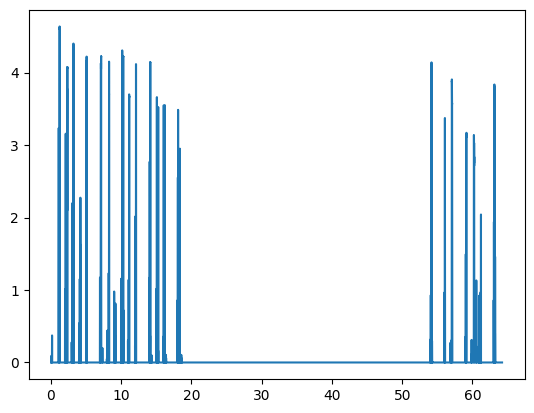

In [14]:
plt.plot(batch.time_series_times.squeeze().cpu().detach().numpy(),batch.time_series.squeeze().cpu().detach().numpy(),label='test')

min intensity_trajectory: 7.8762664794921875


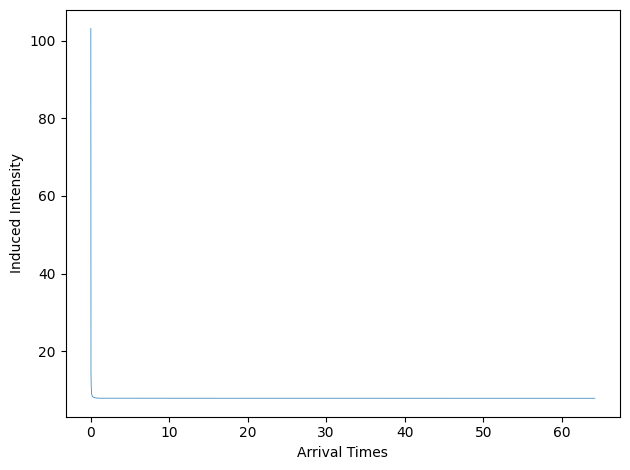

In [15]:
if model.bg_model is not None:
    f_intensity_trajectory = model.bg_model.intensity_trajectory(batch)
    plt.plot(batch.time_series_times.squeeze().cpu().detach().numpy(),
            f_intensity_trajectory.squeeze().cpu().detach().numpy(),label='intensity_trajectory',
            linewidth=0.5,)
    plt.xlabel('Arrival Times')
    plt.ylabel('Induced Intensity')
    plt.tight_layout()
    plt.savefig(checkpoint_dir/'induced_intensity.png')
    print(f"min intensity_trajectory: {f_intensity_trajectory.min().item()}")

In [16]:
model.bg_model.intensity_trajectory(batch)

tensor([[103.1280,  83.2046,  53.3346,  ...,   7.8763,   7.8763,   7.8763]],
       device='cuda:0', grad_fn=<SqueezeBackward1>)

In [82]:
times = batch.time_series_times.squeeze()
mask =  (times >= 0) & (times < 20) 
index = torch.where(mask)[0]         
arr = f_intensity_trajectory.squeeze()[index].detach().cpu().numpy()
print(f"arr min: {arr.min()}, max: {arr.max()}")

arr min: 5.386231899261475, max: 6036.771484375


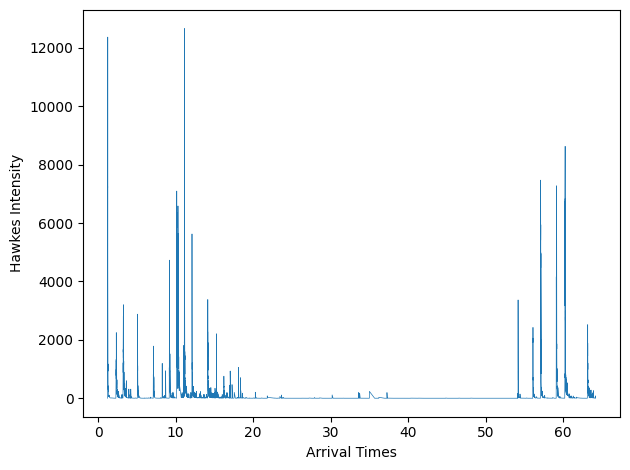

In [28]:
### rtpp
# context = model.get_context(batch)
# inter_time_dist = model.get_inter_time_dist(context)
# log_h_intensity = inter_time_dist.log_hazard(batch.inter_times.clamp_min(1e-10))
# h_intensity = torch.exp(log_h_intensity)
# h_intensity_copied = torch.where(h_intensity > 100000, torch.tensor(0.0, device=h_intensity.device), h_intensity)

# window = 20  # smoothing window size
# arrival_times_np = batch.arrival_times.detach().cpu().numpy().ravel()
# raw_np = h_intensity_copied.detach().cpu().numpy().ravel()
# smoothed = np.convolve(raw_np, np.ones(window) / window, mode='same')

# plt.xlabel('Arrival Times')
# plt.ylabel('History Intensity')
# # plt.plot(arrival_times_np, raw_np, linewidth=0.5, color='tab:blue', label='Raw')
# plt.plot(arrival_times_np, smoothed, linewidth=1.0, color='tab:red', label='Smoothed')
# plt.legend()
# plt.tight_layout()
### etas
h_intensity= model.h_intensity(batch)
plt.plot(
    batch.arrival_times.reshape(-1)[:-1].detach().cpu().numpy(),
    h_intensity.reshape(-1).detach().cpu().numpy(),
    linewidth=0.5,
    color='tab:blue'
)
plt.xlabel('Arrival Times')
plt.ylabel('Hawkes Intensity')
plt.tight_layout()
plt.savefig(checkpoint_dir/'hawkes_intensity.png')

In [29]:
(h_intensity > 1000).sum().item()

4022

We would like to generate a 30-day forecast for the interval `[13000, 13030]`. For this, we select two subsequences:
- `past_seq`: Contains events from `[0, 13000]`, is used to condition the model
- `observed_seq`: Contains actually observed events from `[13000, 13030]`.

In [30]:
t_forecast = 50 # 1460
duration = 3 # 7 30
num_samples = 1000 # 10000

# Past events that we condition on
past_seq = test_seq.get_subsequence(0, t_forecast,reset_t_nll_to_end=True) #  3500
observed_seq = test_seq.get_subsequence(t_forecast, t_forecast + duration,reset_t_nll_to_end=True)

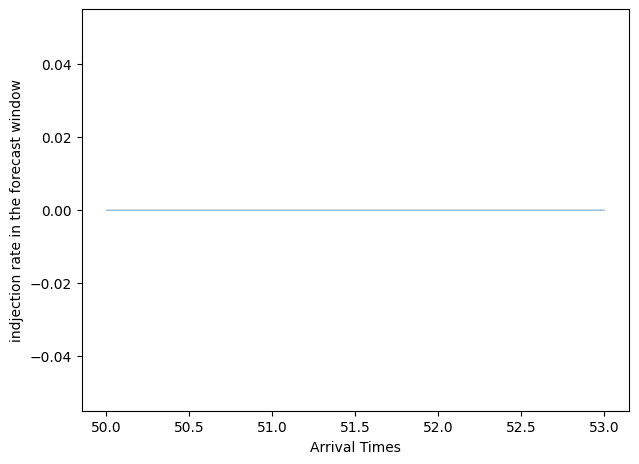

In [31]:
mask  = (test_seq.time_series_times >= t_forecast) & (test_seq.time_series_times < t_forecast + duration)
future_time_series = test_seq.time_series[mask]
future_time_series_times = test_seq.time_series_times[mask]
plt.xlabel('Arrival Times')
plt.ylabel('indjection rate in the forecast window')
plt.tight_layout()
plt.plot(future_time_series_times,
          future_time_series.reshape(-1).detach().cpu().numpy(),
           linewidth=0.5,
         color='tab:blue')

## Generate the forecast

In [58]:
past_batch = src.data.Batch.from_list([past_seq.float()])

In [59]:
past_seq

Sequence(
  inter_times: [3463],
  arrival_times: [3462],
  t_start: 0.0,
  t_end: 14.0,
  t_nll_start: 13.9,
  mag: [3462],
  loc: [3462, 2],
  depth: [3462],
  time_series: [20105, 1],
  time_series_times: [20105]
)

In [60]:
if torch.cuda.is_available():
    model.to('cuda:0')
    past_seq.to('cuda:0')

intensity before squeeze min: 5.765549182891846, max: 6018.6201171875
intensity before squeeze min: 7.626301288604736, max: 4684.95361328125


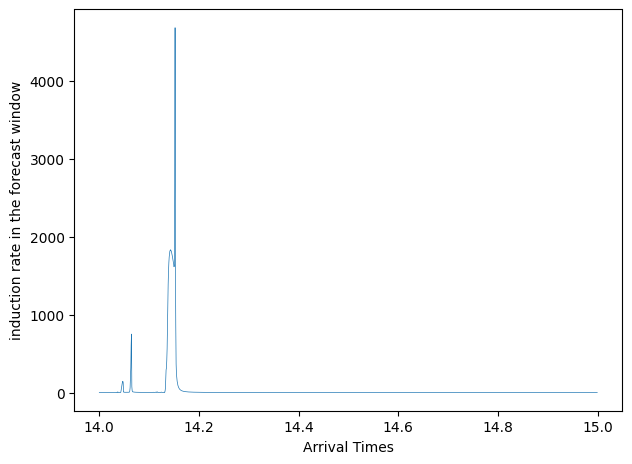

In [61]:
if model.bg_model is not None:
    model.bg_model.cache_batch(time_series=test_seq.time_series.unsqueeze(0), time_series_times=test_seq.time_series_times.unsqueeze(0))
    model.bg_model.ts_batch_cache
    times_all = test_seq.time_series_times
    mask = (times_all >= t_forecast) & (times_all < t_forecast + duration)
    f_intensity = model.bg_model.intensity(ts_batch=model.bg_model.ts_batch_cache,t_query=times_all[mask].unsqueeze(0))
    plt.xlabel('Arrival Times')
    plt.ylabel('induction rate in the forecast window')
    plt.tight_layout()
    plt.plot(times_all[mask], f_intensity.reshape(-1).detach().cpu().numpy(), linewidth=0.5, color='tab:blue')

In [62]:
observed_seq.arrival_times

tensor([14.0003, 14.0025, 14.0196, 14.0321, 14.0364, 14.0643, 14.0839, 14.1155,
        14.1376, 14.1378, 14.1381, 14.1382, 14.1384, 14.1404, 14.1405, 14.1417,
        14.1421, 14.1422, 14.1422, 14.1433, 14.1439, 14.1442, 14.1446, 14.1457,
        14.1459, 14.1462, 14.1463, 14.1469, 14.1469, 14.1470, 14.1478, 14.1488,
        14.1495, 14.1500, 14.1504, 14.1505, 14.1507, 14.1507, 14.1508, 14.1509,
        14.1511, 14.1511, 14.1513, 14.1514, 14.1519, 14.1522, 14.1529, 14.1532,
        14.1537, 14.1539, 14.1543, 14.1544, 14.1544, 14.1545, 14.1546, 14.1547,
        14.1550, 14.1550, 14.1550, 14.1550, 14.1551, 14.1552, 14.1554, 14.1555,
        14.1557, 14.1557, 14.1560, 14.1569, 14.1571, 14.1572, 14.1572, 14.1574,
        14.1578, 14.1588, 14.1591, 14.1592, 14.1599, 14.1599, 14.1607, 14.1612,
        14.1612, 14.1613, 14.1619, 14.1620, 14.1628, 14.1630, 14.1647, 14.1657,
        14.1662, 14.1665, 14.1673, 14.1681, 14.1683, 14.1685, 14.1685, 14.1690,
        14.1693, 14.1696, 14.1697, 14.17

231

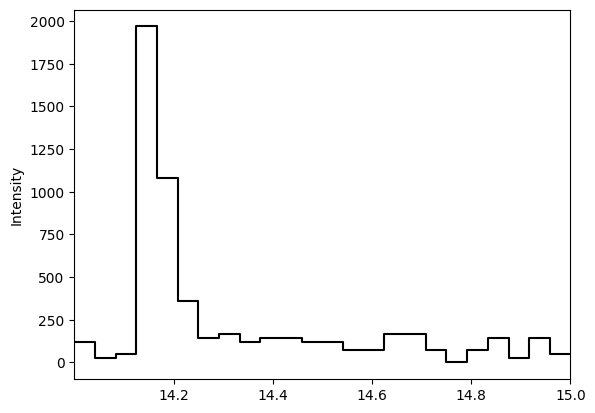

In [63]:
from src.utils.visualization import  plot_intensity
plot_intensity(observed_seq,dt=1/24)
len(observed_seq)

In [64]:
if model.bg_model is not None:
    model.bg_model.cache_batch(time_series=test_seq.time_series.unsqueeze(0), time_series_times=test_seq.time_series_times.unsqueeze(0))

intensity before squeeze min: 5.765549182891846, max: 6018.6201171875


In [65]:
if model.bg_model is not None:
    no = model.bg_model.forecast_count(t_forecast, t_forecast + duration)
    print(f"Forecasted background count from {t_forecast} to {t_forecast + duration}: {no}")
    # model.bg_model.forecast_count(t_forecast+5, t_forecast + 10)

Forecasted background count from 14 to 15: 43.32916259765625


In [66]:
# model.bg_model.set_scale(0)   
# model.bg_model._scale   
# model.M_m = torch.tensor(6.5)
# model.set_params(mu=0.26,c=0.58,p=1.51,K=0.77,alpha_e=0.66)
model.print_params()

ETAS model parameters:
  p = 1.9986785132965583
  c = 0.004260559696216268
  mu = 0.11906653718314032
  k = 0.0028706185629230234
  K = 0.6698082613664758
  alpha = 0.20968953929494355
  alpha_e = 0.4828280073373262
  b = 1.2355434894561768
  M_c = -1.5
  M_m = 10.0


In [67]:
model.nll_loss(train_batch), model.nll_loss(test_batch)

intensity before squeeze min: 7.743342876434326, max: 4783.095703125
intensity max: 12667.29296875, f_intensity max: 4783.095703125,mu max: 0.11906653718314032
intensity before squeeze min: 7.819789886474609, max: 1773.19091796875
intensity max: 8631.173828125, f_intensity max: 1773.19091796875,mu max: 0.11906653718314032


(tensor([-592.0723], device='cuda:0', grad_fn=<DivBackward0>),
 tensor([-1198.5701], device='cuda:0', grad_fn=<DivBackward0>))

In [68]:
set_seed(3) 
model.eval()  # Set the model to evaluation mode
all_forecasts = []
samples_per_batch = 1000
for _ in range(max(num_samples // samples_per_batch,1)):
    # forecast = model.sample(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True, max_sample_len=4000)
    forecast = model.sample(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True,t_max=100)
    all_forecasts.extend(forecast)

  0%|          | 0/1000 [00:00<?, ?it/s]

/root/autodl-tmp/chuandian_eq/src/data/sequence.py:246: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/chuandian_eq/src/data/sequence.py:246: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/chuandian_eq/src/data/sequence.py:246: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/chuandian_eq/src/data/sequence.py:246: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/chuandian_eq/src/data/sequence.py:246: User

In [69]:
zero_indices = []
for idx, fc in enumerate(all_forecasts):
    t = torch.as_tensor(fc.inter_times).cpu()
    if (t == 0).any():
        zero_indices.append(idx)

if zero_indices:
    print("Found zeros in inter_times at indices:", zero_indices)
else:
    print("No zeros found in inter_times of any forecast.")
print("Number of forecasts with zero inter_times:", len(zero_indices))

Found zeros in inter_times at indices: [34, 41, 54, 89, 123, 164, 183, 195, 199, 248, 272, 387, 388, 390, 410, 418, 421, 454, 508, 535, 554, 575, 581, 612, 633, 659, 723, 824, 885, 924, 938]
Number of forecasts with zero inter_times: 31


`forecast` is a list, where each element is a `eq.data.Sequence` that represents a possible continuation of the catalog over the interval `[13000, 13030]`.

With the following function, we
- visualize 10 randomly chosen trajectories as a counting process
- plot the distribution of the total # of events in the forecast interval

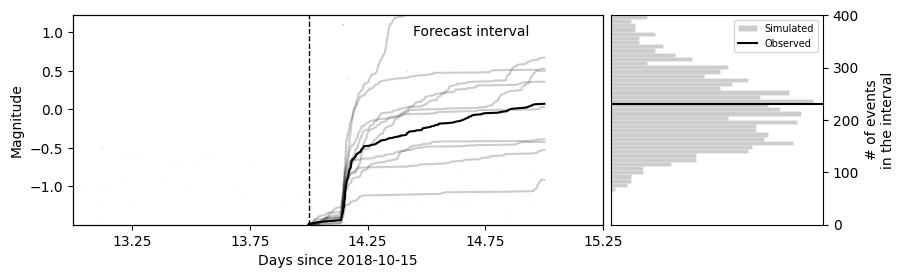

In [70]:
date_str = catalog_ds.metadata['start_ts'].strftime('%Y-%m-%d')
src.utils.visualization.visualize_trajectories(test_seq, all_forecasts,save_path=checkpoint_dir/"all_forecasts.pdf",figsize=(10,3),xlabel='Days since '+date_str,reset_t_nll_to_end=True)

In [71]:
import  src.utils.catalog_tests as catalog_tests

In [72]:
test_seq

Sequence(
  inter_times: [6141],
  arrival_times: [6140],
  t_start: 0.0,
  t_end: 64.208,
  t_nll_start: 59.667,
  mag: [6140],
  loc: [6140, 2],
  depth: [6140],
  time_series: [92404, 1],
  time_series_times: [92404]
)

RMSE

In [73]:
fc_dist = np.array([len(fc) for fc in all_forecasts])
ob = len(observed_seq)
rmse = np.sqrt(np.mean((fc_dist - ob)**2))
print(f"RMSE: {rmse}")

RMSE: 76.04666330615697


N-test

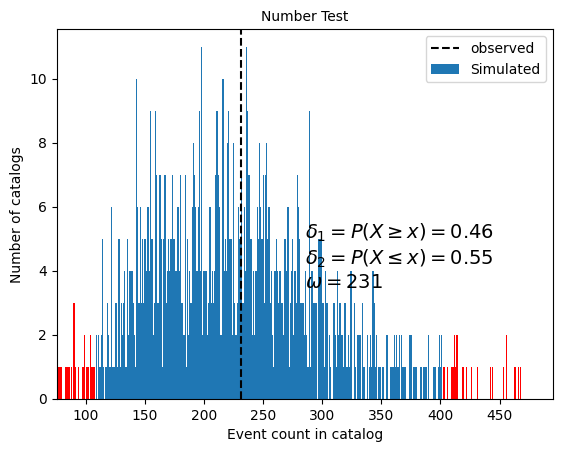

In [74]:
number_test_result = catalog_tests.run_number_test_result(
    event_counts=[len(fc) for fc in all_forecasts],
    obs_count=len(observed_seq),                   
    min_mw=catalog_ds.metadata['mag_completeness'],
    obs_name='observed',
    sim_name='Simulated',
    plot=False
)
ax= number_test_result.plot(plot_args={'figsize':(6.4,4.8),'tight_layout':False})
plt.savefig(checkpoint_dir/'n_test.pdf')

In [75]:
mag_max = [all_forecasts[i].mag.max().item() for i in range(len(all_forecasts))]
mag_min = [all_forecasts[i].mag.min().item() for i in range(len(all_forecasts))]
max(mag_max), min(mag_min)

(2.6280360634830706, -1.499999709425054)

In [76]:
observed_seq.mag.max().item(), observed_seq.mag.min().item()

(1.100000023841858, -1.4989999532699585)

M-test

In [77]:
config_dict = {
    'min_mw': catalog_ds.metadata['mag_completeness'],
    'max_mw': 5,
    'dmw': 0.01
}

magnitude_bins, distribution = catalog_tests.compute_magnitude_distribution(
    forecast[0].mag.cpu().numpy(), 
   **config_dict
)

In [78]:
import matplotlib
importlib.reload(src.utils.catalog_tests)

<module 'src.utils.catalog_tests' from '/root/autodl-tmp/chuandian_eq/src/utils/catalog_tests.py'>

In [79]:
get_counts = functools.partial(catalog_tests.compute_magnitude_distribution, **config_dict)
result_dict = catalog_tests.magnitude_test_from_counts(
    observed_catalog=observed_seq,
    forecast_catalogs=all_forecasts[:10],
    get_counts=lambda cat: get_counts(np.asarray(cat.mag.cpu()))[1],
    verbose=False,  
    debug=False
)

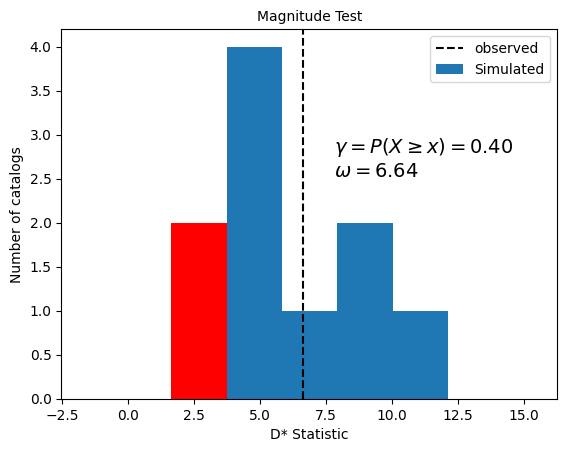

In [80]:
magnitude_test_result = catalog_tests.run_magnitude_test_result(
    result_dict=result_dict,
    obs_catalog_repr='obs',
   obs_name='observed',
    sim_name='Simulated',
    plot=False
)
magnitude_test_result.plot(plot_args={'figsize':(6.4,4.8),'tight_layout':False})
plt.savefig(checkpoint_dir/'m_test.pdf')

In [81]:
start = int(test_seq.arrival_times[0].item())
end   = int(test_seq.arrival_times[-1].item())
start = int(test_seq.arrival_times[0].item())
end   = int(test_seq.arrival_times[-1].item())

duration = 1
slide_step = 1
quantiles = (2.5, 97.5)
samples_per_batch = 1000

# Use np.arange to support float start, stop, and step values
t_forecast_list = np.arange(start + duration, end - duration, slide_step)

counts_list = []
q_list = []
mean_list = []
forecasts_counts_list = []

model.eval()

for t_forecast in t_forecast_list:
    print(f"Forecasting at t={t_forecast:.2f}")
    t_end = min(t_forecast + duration, end)

    past_seq = test_seq.get_subsequence(
        0, t_forecast, reset_t_nll_to_end=True
    ).to(device)
    observed_seq = test_seq.get_subsequence(
        t_forecast, t_end, reset_t_nll_to_end=True
    ).to(device)

    all_forecasts = model.sample(
        batch_size=samples_per_batch,
        duration=(t_end - t_forecast),
        past_seq=past_seq,
        return_sequences=True
    )

    forecasts_counts = np.fromiter((len(fc) for fc in all_forecasts), dtype=np.int32)

    q = np.percentile(forecasts_counts, quantiles)
    mean = forecasts_counts.mean()

    q_list.append(q)
    mean_list.append(mean)
    true_counts = len(observed_seq)
    counts_list.append(true_counts)
    forecasts_counts_list.append(forecasts_counts)



Forecasting at t=2.00


  0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

acceptance rate: 45.90%


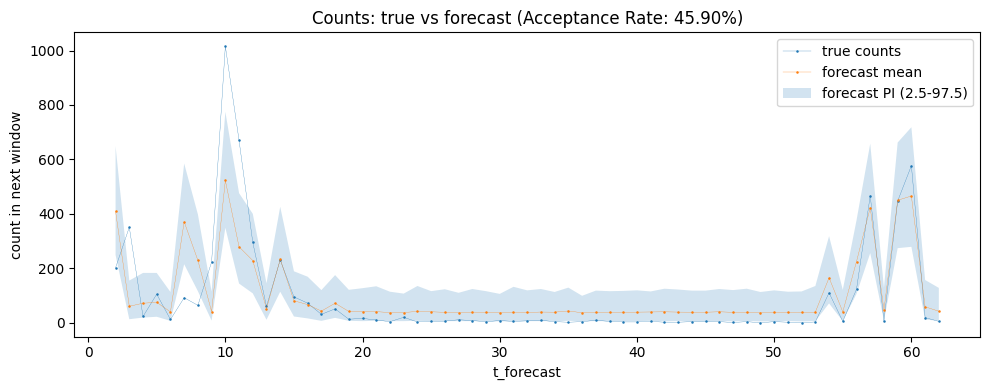

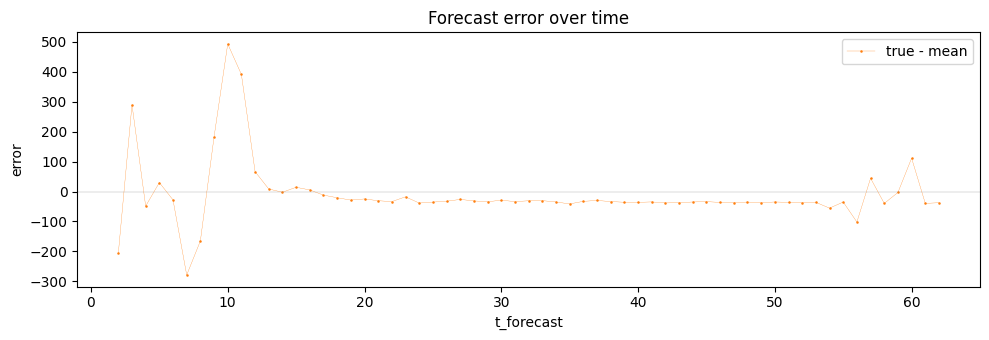

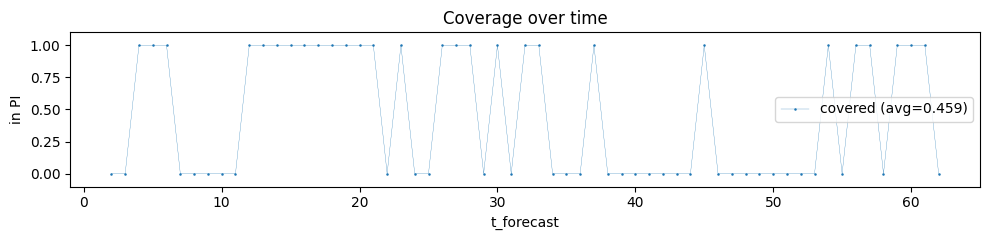

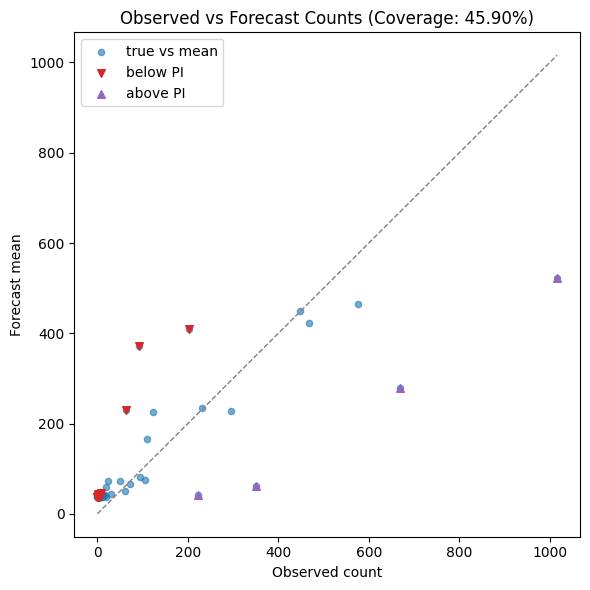

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array(list(t_forecast_list))
counts = np.array(counts_list)                  # shape: (T,)
means  = np.array(mean_list)                    # shape: (T,)
qs     = np.array(q_list)                       # shape: (T, 2)  -> [low, high]
q_low, q_high = qs[:, 0], qs[:, 1]
counts = np.array(counts_list)
qs = np.array(q_list)
q_low, q_high = qs[:, 0], qs[:, 1]

covered = (counts >= q_low) & (counts <= q_high)
coverage = covered.mean()
print(f"acceptance rate: {coverage:.2%}")


plt.figure(figsize=(10,4))
plt.plot(x, counts, label="true counts",linewidth=0.2,marker='o',markersize=0.8)
plt.plot(x, means,  label="forecast mean",linewidth=0.2,marker='o',markersize=0.8)
plt.fill_between(x, q_low, q_high, alpha=0.2, label="forecast PI (2.5-97.5)")
plt.xlabel("t_forecast")
plt.ylabel("count in next window")
plt.title(f"Counts: true vs forecast (Acceptance Rate: {coverage:.2%})")
plt.legend()
plt.tight_layout()
plt.savefig(checkpoint_dir/'forecast_counts_over_time.png')
plt.show()

err = counts - means
plt.figure(figsize=(10,3.5))
plt.plot(x, err, label="true - mean",linewidth=0.2,marker='o',markersize=0.8,color='tab:orange')
plt.axhline(0,linewidth=0.2,color='gray')
plt.xlabel("t_forecast")
plt.ylabel("error")
plt.title("Forecast error over time")
plt.legend()
plt.tight_layout()
plt.savefig(checkpoint_dir/'forecast_error_over_time.png')
plt.show()


covered = (counts >= q_low) & (counts <= q_high)
coverage = covered.mean()
plt.figure(figsize=(10,2.5))
plt.plot(x, covered.astype(int), label=f"covered (avg={coverage:.3f})",linewidth=0.2,marker='o',markersize=0.8)
plt.ylim(-0.1, 1.1)
plt.xlabel("t_forecast")
plt.ylabel("in PI")
plt.title("Coverage over time")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))


plt.scatter(counts, means,
            color='tab:blue', alpha=0.6,
            s=20, label="true vs mean")
out_of_lower = counts < q_low
out_of_upper = counts > q_high

plt.scatter(counts[out_of_lower], means[out_of_lower],
            color='tab:red', marker='v', s=30,
            label="below PI")

plt.scatter(counts[out_of_upper], means[out_of_upper],
            color='tab:purple', marker='^', s=30,
            label="above PI")
min_val = min(counts.min(), means.min())
max_val = max(counts.max(), means.max())
plt.plot([min_val, max_val], [min_val, max_val],
         linestyle='--', color='gray', linewidth=1)

plt.xlabel("Observed count")
plt.ylabel("Forecast mean")
plt.title(f"Observed vs Forecast Counts (Coverage: {coverage:.2%})")
plt.legend()
plt.tight_layout()

plt.savefig(checkpoint_dir/'obs_vs_forecast_scatter.png')
plt.show()

